# Photoluminescence from monolayer WSe$_2$, on the BigTable

The same material as `example_1L_WSe2.ipynb` and the same questions asked of it —
how the PL moves as the carrier density changes, and as the out-of-plane field
changes — but measured on a different setup, which writes a different file.

The point of this notebook is that **almost nothing here is about the
instrument**. Once the file is loaded, every correction, both spectral axes,
every plotting function and every fit are the same calls. What changes is three
lines of the constructor.

In [1]:
from tmdc_optics_tools.loaders import (
    BigTableSpectralSweep, StackLayer, DeviceGeometry,
)
from tmdc_optics_tools.plotting import (
    plot_spectral_map, plot_spectrum, plot_spectral_series,
)
from tmdc_optics_tools.fitting import fit_scan_peak

import matplotlib.pyplot as plt
import numpy as np
import cmocean, cmcrameri
from pathlib import Path

## What is different about a BigTable export

Three things, and they are the whole reason there is a second class.

**The parameter rows have no names in the file.** The AttoCube export has a label
column, so `scan.parameters` is keyed by the exporter's own strings (`"V_A"`,
`"Excitation Power"`). A BigTable export has no labels at all: the parameter
column is positional. So the names below are *this package's*, established from
what the numbers do and recorded in `dev/instruments/big-table.md`. Rows whose
meaning is not established keep a positional name like `Row 13` rather than a
guessed one.

**Which gate is top and which is bottom varies between samples**, so nothing is
assumed. `gates=` is where you say it, once, and it travels with the scan.

**Excitation power is already in microwatts.** No scale factor, unlike the
AttoCube's photodiode voltage.

In [2]:
geom = DeviceGeometry(
    d_hbn_top = 30,
    d_hbn_bottom = 26,
    tmdc_stack = [StackLayer("WSe2")],
    label = "hBN/WSe2/hBN"
)

SWEEP_DEFAULTS = dict(
    spectra_type = "PL",                    # required: no file records this
    gates = {                               # per sample on this setup, so declared
        "top"     : "Gate Voltage 2",       #   every time rather than defaulted
        "bottom"  : "Gate Voltage 1",
        "channel" : None,                   # grounded, and no row records it
    },
    geometry = geom,
    bg_region_nm = [705, 715],              # a dark window at the blue end
    apply_jacobian = True,
    cosmic_rays = {},
)

filepath = Path('./data/big-table-spectral')

## The field sweep

`PL_Ez_*` sweeps the two gates in **opposite** directions, which holds the
carrier density near zero and moves the out-of-plane field. Declaring
`sweep="electric_field"` is what turns the two voltage rows into a field axis;
that needs the geometry, which is why `geom` is in the defaults above.

In [3]:
ez = BigTableSpectralSweep(
    path = sorted(filepath.glob("PL_Ez_*.csv"))[0],
    sweep = "electric_field",
    **SWEEP_DEFAULTS
)

print(ez)

BigTableSpectralSweep — 101 sweeps × 1340 pixels  [Photoluminescence]
  File        : data\big-table-spectral\PL_Ez_1LWSe2_p20uW_exp1sec_250508_190009.csv
  λ range     : 702.0 – 978.0 nm
  Energy range: 1.268 – 1.766 eV
  Sweep       : electric_field — -99.19 → 98.7 mV/nm
  Gates       : dual-gate, anti-correlated (field-like)  (top ← 'Gate Voltage 2', bottom ← 'Gate Voltage 1', channel ← grounded)
  Power       : 19.7 → 25.3 µW
  Varying     : Gate Voltage 2, Gate Voltage 1, Gate Current 1, Gate Current 2
  Cosmic rays : 8254 pixels replaced
  BG region   : 705.0 – 715.0 nm
  Jacobian    : applied



C:\Users\Brandon\Documents\04_Areas\LANES-TMDC-Optics-Tools\src\tmdc_optics_tools\loaders.py:4066: UserWarning: 392 flagged pixel(s) kept their raw values because every pixel in their median_window=7 window was flagged too: pixel 154 (sweep 0), pixel 169 (sweep 0), pixel 170 (sweep 0), .... A run of flagged pixels that wide has no unflagged neighbour left to take a median from, so part of the spike survives the repair. Pass a larger median_window to reach it.
  self.spectra_cr, self.cosmic_ray_mask = processing.remove_cosmic_rays(


Read the `Gates` line: nothing told the loader this was a field sweep. It
compares the two declared gate rows and reports what it finds. The filename
agrees, which is a useful check that the positional row map is right.

`Varying` is **evidence, not a detector** — it ranks rows by how far each moved
against its own size, so a small leakage current can outrank the gate that was
actually swept. Watch `Row 12` below: it moves by about a microamp and still
outranks the excitation power, because relative to its own magnitude it swings
across its whole range. Which axis was scanned is always declared, never guessed.

In [4]:
print(ez.gate_mode)
print()
for label, (lo, hi, span) in list(ez.varying_parameters().items())[:6]:
    print(f"{label:20s} {lo:+12.4g} -> {hi:+12.4g}   (span {span:.4g})")

dual-gate, anti-correlated (field-like)

Gate Voltage 2             -5.582 ->       +5.605   (span 11.19)
Gate Voltage 1             -4.999 ->       +4.969   (span 9.968)
Gate Current 1           -0.02155 ->      +0.4347   (span 0.4563)
Gate Current 2            -0.4184 ->      +0.0124   (span 0.4308)
Row 12                 -1.232e-06 ->   +1.322e-07   (span 1.364e-06)
Excitation Power           +19.74 ->        +25.3   (span 5.56)


### The positional row map

Ten rows are named; the rest keep their position as their name. An unnamed row
is not a lost row — it is still readable, and still usable as a sweep axis — so
leaving it unnamed costs nothing, while a wrong name would reach every figure
axis and every saved file.

In [5]:
named   = sorted(k for k in ez.parameters if not k.startswith("Row "))
unnamed = sorted((k for k in ez.parameters if k.startswith("Row ")),
                 key=lambda s: int(s.split()[1]))

print("named:  ", named)
print()
print("unnamed:", [k for k in unnamed if ez.parameters[k].any()],
      "carry a value")
print("        ", [k for k in unnamed if not ez.parameters[k].any()],
      "are zero throughout")
print()
print("power:", f"{ez.power.min():.1f} - {ez.power.max():.1f}",
      ez.curated_parameters["power"][2], "- no scale factor")

named:   ['Excitation Power', 'Gate Current 1', 'Gate Current 2', 'Gate Voltage 1', 'Gate Voltage 2', 'Gate Voltage 3', 'Reflection', 'X Position', 'Y Position', 'Z Position']

unnamed: ['Row 12', 'Row 13', 'Row 17', 'Row 30'] carry a value
         ['Row 10', 'Row 14', 'Row 15', 'Row 16', 'Row 18', 'Row 19', 'Row 20', 'Row 21', 'Row 22', 'Row 23', 'Row 24', 'Row 25', 'Row 26', 'Row 27', 'Row 28', 'Row 29'] are zero throughout

power: 19.7 - 25.3 µW - no scale factor


## Plotting is unchanged

Every call below is the one an AttoCube scan takes. Nothing downstream knows or
needs to know which instrument wrote the file.

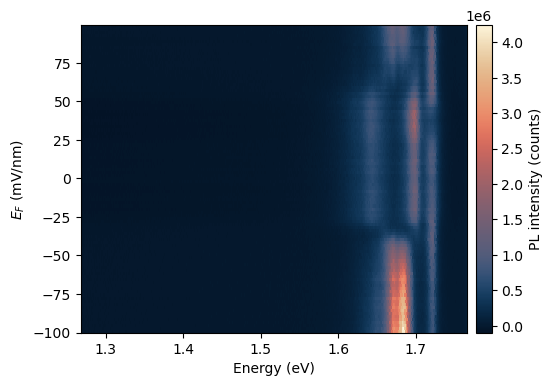

In [6]:
fig, ax, mesh = plot_spectral_map(
    ez,
    cmap = 'cmc.lipari'
)

The neutral exciton moves down and broadens as the field grows in either
direction — symmetric about zero field, which is what the map should look like if
the two gates really are capacitance-matched.

A series is often easier to read than a map when the change is in the lineshape
rather than the position.

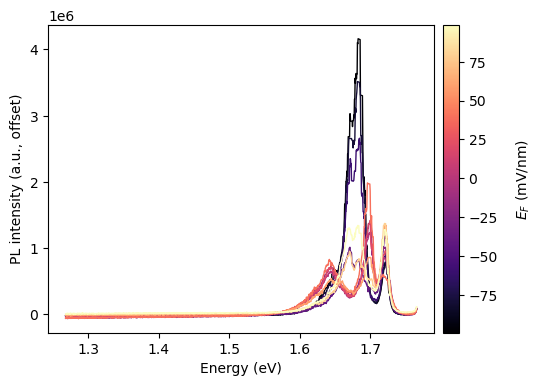

In [7]:
fig, ax, cb, lines, ax_twin = plot_spectral_series(
    ez, sweep_step = 10, spectrum_offset = 4000,
)

And a single spectrum at one point on the axis. `value=0.0` selects by
coordinate, not by index, so this is the spectrum at zero field whatever the
sweep length.

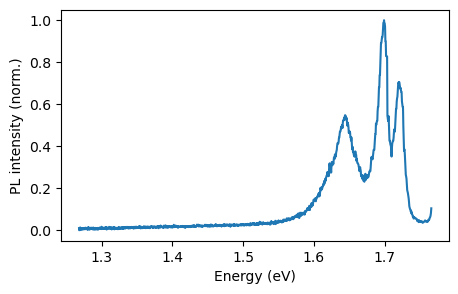

In [8]:
fig, ax, line, ax_twin = plot_spectrum(
    ez, value = 0.0, normalize = True, x_axis = 'energy'
)

## The doping sweep

`PL_Doping_*` sweeps the same two gates **together**, which holds the field near
zero and moves the carrier density. The only change is `sweep=`.

In [9]:
doping = BigTableSpectralSweep(
    path = sorted(filepath.glob("PL_Doping_*.csv"))[0],
    sweep = "carrier_density",
    **SWEEP_DEFAULTS
)

print(doping)

BigTableSpectralSweep — 61 sweeps × 1340 pixels  [Photoluminescence]
  File        : data\big-table-spectral\PL_Doping_1LWSe2_p20uW_exp1sec_250508_190421.csv
  λ range     : 702.0 – 978.0 nm
  Energy range: 1.268 – 1.766 eV
  Sweep       : carrier_density — -4.904e+12 → 4.885e+12 cm$^{-2}$
  Gates       : dual-gate, correlated (doping-like)  (top ← 'Gate Voltage 2', bottom ← 'Gate Voltage 1', channel ← grounded)
  Power       : 20.0 → 23.1 µW
  E_F         : -3.3 → 3.4 mV/nm
  Varying     : Gate Current 2, Gate Current 1, Gate Voltage 2, Gate Voltage 1
  Cosmic rays : 4637 pixels replaced
  BG region   : 705.0 – 715.0 nm
  Jacobian    : applied



C:\Users\Brandon\Documents\04_Areas\LANES-TMDC-Optics-Tools\src\tmdc_optics_tools\loaders.py:4066: UserWarning: 268 flagged pixel(s) kept their raw values because every pixel in their median_window=7 window was flagged too: pixel 149 (sweep 0), pixel 129 (sweep 5), pixel 130 (sweep 5), .... A run of flagged pixels that wide has no unflagged neighbour left to take a median from, so part of the spike survives the repair. Pass a larger median_window to reach it.
  self.spectra_cr, self.cosmic_ray_mask = processing.remove_cosmic_rays(


Two files, one loader, and the loader tells them apart from the numbers alone:

In [10]:
for name, scan in [("PL_Ez", ez), ("PL_Doping", doping)]:
    print(f"{name:12s} {scan.gate_mode}")
    print(f"{'':12s} field   {scan.ef.min():+8.1f} to {scan.ef.max():+8.1f} mV/nm")
    print(f"{'':12s} density {scan.carrier_density.min():+.2e} to "
          f"{scan.carrier_density.max():+.2e} cm^-2")
    print()

PL_Ez        dual-gate, anti-correlated (field-like)
             field      -99.2 to    +98.7 mV/nm
             density -1.28e+11 to +1.24e+11 cm^-2

PL_Doping    dual-gate, correlated (doping-like)
             field       -3.3 to     +3.4 mV/nm
             density -4.90e+12 to +4.88e+12 cm^-2



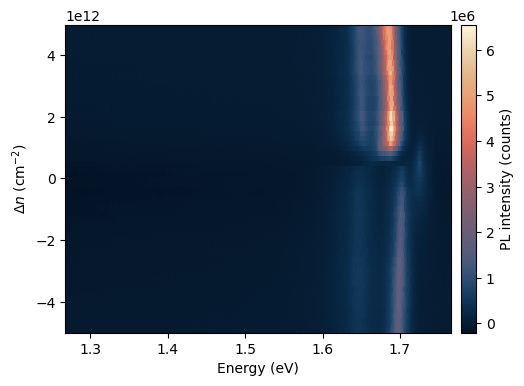

In [11]:
fig, ax, mesh = plot_spectral_map(
    doping,
    cmap = 'cmc.lipari'
)

The trion appears on both sides of charge neutrality and the neutral exciton
loses weight to it — the ordinary doping picture, and a useful sanity check that
the density axis has the right sign and scale.

## Fitting across the sweep

`fit_scan_peak` takes the scan and a window, and fits every sweep point. It reads
the most-corrected spectra present, so the background subtraction and Jacobian
declared at load time are already in what it fits.

lorentzian+constant -> ['amplitude', 'center', 'fwhm', 'offset']


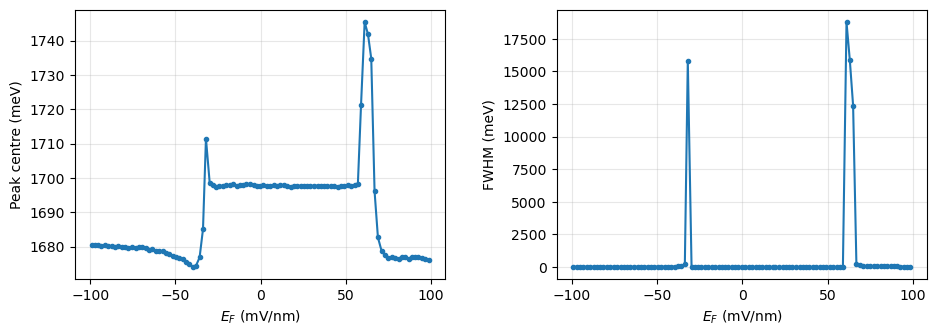

In [12]:
fits = fit_scan_peak(ez, x_range = (1.60, 1.70))

# One FitResult per sweep point. The fitted values live in `.params`, keyed by
# the model's own parameter names, so a different model reads the same way.
print(fits[0].model, "->", list(fits[0].params))

centres = np.array([f.params["center"] for f in fits])
widths  = np.array([f.params["fwhm"]   for f in fits])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), gridspec_kw={'wspace': 0.3})
axes[0].plot(ez.sweep_axis, centres * 1e3, 'o-', ms=3)
axes[0].set(xlabel=ez.sweep_axis_label, ylabel="Peak centre (meV)")
axes[1].plot(ez.sweep_axis, widths * 1e3, 'o-', ms=3)
axes[1].set(xlabel=ez.sweep_axis_label, ylabel="FWHM (meV)")
for a in axes:
    a.grid(alpha=0.3)

## What this loader will not do yet

**Save to HDF5.** The archive format records which axis a file holds but not
which instrument wrote it, so a saved BigTable sweep would read back as an
`AttoCubeSpectralSweep`. Rather than write a file that lies, both directions
refuse and say why. Load the raw `.csv`.

**Read a nest without being told.** If this setup ever writes a 2-D raster
flattened into one file, it arrives with no statement of its shape, exactly as
the AttoCube's does — `fast_sweep=` and `slow_sweep=` are how you declare it. No
such file has been seen yet.

In [13]:
try:
    ez.to_hdf5("scratch.h5")
except NotImplementedError as exc:
    print(exc)

A BigTableSpectralSweep cannot be written as HDF5 yet. The archive format records which axis a file holds but not which instrument wrote it, so it cannot tell a BigTable scan from an AttoCube one and a saved sweep would read back as the wrong class. Load the raw .csv export instead.


## Where the format is written down

`dev/instruments/big-table.md` is the record: what each parameter row was
established from, which rows are still unidentified, and — read this before
trusting a row name — why the naming counts as inherited group practice rather
than a specification.